# Smart Logistics Internship Project - Day 3
## Complete Univariate Analysis

Welcome to Day 3! Today, we will dive deep into understanding each individual variable in our dataset. Univariate analysis is crucial for discovering patterns, understanding the distribution of our data, and identifying potential outliers.

### Day 3 Objectives:
1. **Numerical Analysis:** For every numerical column, we will calculate Mean, Median, Mode, Variance, Standard Deviation, Minimum, Maximum, Quartiles, and plot Histograms, Boxplots, and Density Plots.
2. **Categorical Analysis:** For every categorical column, we will calculate Count, Frequency, Percentage, and plot Bar Charts and Pie Charts.
3. **Interpretations & Business Insights:** Every chart will be interpreted with professional markdown explanations to extract real business value.


### 1. Set Up and Load Clean Data
We'll begin by importing the required libraries and loading our processed logistics dataset from Day 2.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the processed dataset
file_path = r"C:\Users\HP\Downloads\smart_logistics_dataset_updated.xlsx"
df = pd.read_excel(file_path)

# Explicitly cast Timestamp to datetime for completeness
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Treat Logistics_Delay as categorical for proper analysis
df['Logistics_Delay'] = df['Logistics_Delay'].astype(str)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1000, 16)


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Heavy,38,320,4,Traffic Congestion,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,On Schedule,22.5,54.3,Heavy,16,439,7,NaN,80.9,174,0
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,Delayed,25.2,62.2,Heavy,34,355,3,Low Inventory,99.2,260,1
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delayed,25.4,52.3,Heavy,37,227,5,Low Inventory,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Heavy,56,197,6,Traffic Congestion,71.6,270,1


### 2. Helper Functions for Automated Analysis
To maintain clean and DRY (Don't Repeat Yourself) code, we define functions to calculate statistics and plot charts for numerical and categorical variables.


In [2]:
def analyze_numerical(column_name, data):
    print(f"--- {column_name} ---")
    
    # Statistical measures
    mean_val = data[column_name].mean()
    median_val = data[column_name].median()
    mode_val = data[column_name].mode()[0]
    variance_val = data[column_name].var()
    std_val = data[column_name].std()
    min_val = data[column_name].min()
    max_val = data[column_name].max()
    q1 = data[column_name].quantile(0.25)
    q2 = data[column_name].quantile(0.50)
    q3 = data[column_name].quantile(0.75)
    
    stats_df = pd.DataFrame({
        'Measure': ['Mean', 'Median', 'Mode', 'Variance', 'Standard Deviation', 'Minimum', 'Maximum', 'Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)'],
        'Value': [mean_val, median_val, mode_val, variance_val, std_val, min_val, max_val, q1, q2, q3]
    })
    display(stats_df.style.format({'Value': "{:.2f}"}))
    
    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histogram
    sns.histplot(data[column_name], kde=False, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {column_name}')
    
    # Boxplot
    sns.boxplot(x=data[column_name], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {column_name}')
    
    # Density Plot
    sns.kdeplot(data[column_name], fill=True, ax=axes[2], color='salmon')
    axes[2].set_title(f'Density Plot of {column_name}')
    
    plt.tight_layout()
    plt.show()

def analyze_categorical(column_name, data):
    print(f"--- {column_name} ---")
    
    # Frequencies and Percentages
    count_series = data[column_name].value_counts()
    percent_series = data[column_name].value_counts(normalize=True) * 100
    
    summary_df = pd.DataFrame({
        'Count': count_series,
        'Frequency': count_series,  # Count is frequency
        'Percentage (%)': percent_series
    })
    display(summary_df.style.format({'Percentage (%)': "{:.2f}%"}))
    
    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bar Chart
    sns.barplot(x=count_series.index, y=count_series.values, ax=axes[0], palette='red')
    axes[0].set_title(f'Bar Chart of {column_name}')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie Chart
    axes[1].pie(count_series.values, labels=count_series.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(count_series)))
    axes[1].set_title(f'Pie Chart of {column_name}')
    
    plt.tight_layout()
    plt.show()


### 3. Univariate Analysis: Numerical Columns
We will analyze each numerical metric to understand distributions, central tendencies, and dispersions.


#### 3.x. Inventory_Level

--- Inventory_Level ---


,Measure,Value
0,Mean,297.92
1,Median,299.00
2,Mode,403.00
3,Variance,12894.69
4,Standard Deviation,113.55
5,Minimum,100.00
6,Maximum,500.00
7,Q1 (25%),201.00
8,Q2 (50%),299.00
9,Q3 (75%),399.00


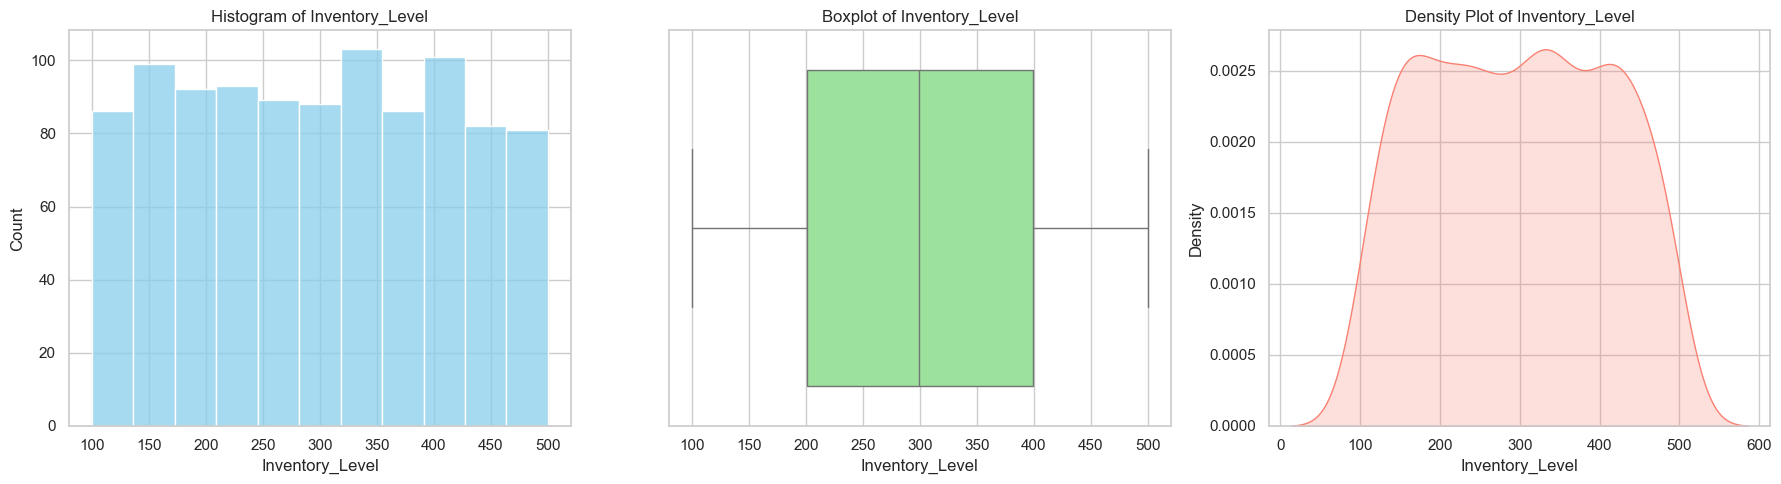

In [3]:
analyze_numerical('Inventory_Level', df)

**Interpretation & Insight:**
The histogram and density plot show the distribution of stock levels across facilities. The boxplot helps identify if there are warehouses operating at unusually high or low inventory extremes.

#### 3.x. Temperature

--- Temperature ---


,Measure,Value
0,Mean,23.89
1,Median,23.80
2,Mode,22.80
3,Variance,11.04
4,Standard Deviation,3.32
5,Minimum,18.00
6,Maximum,30.00
7,Q1 (25%),21.20
8,Q2 (50%),23.80
9,Q3 (75%),26.60


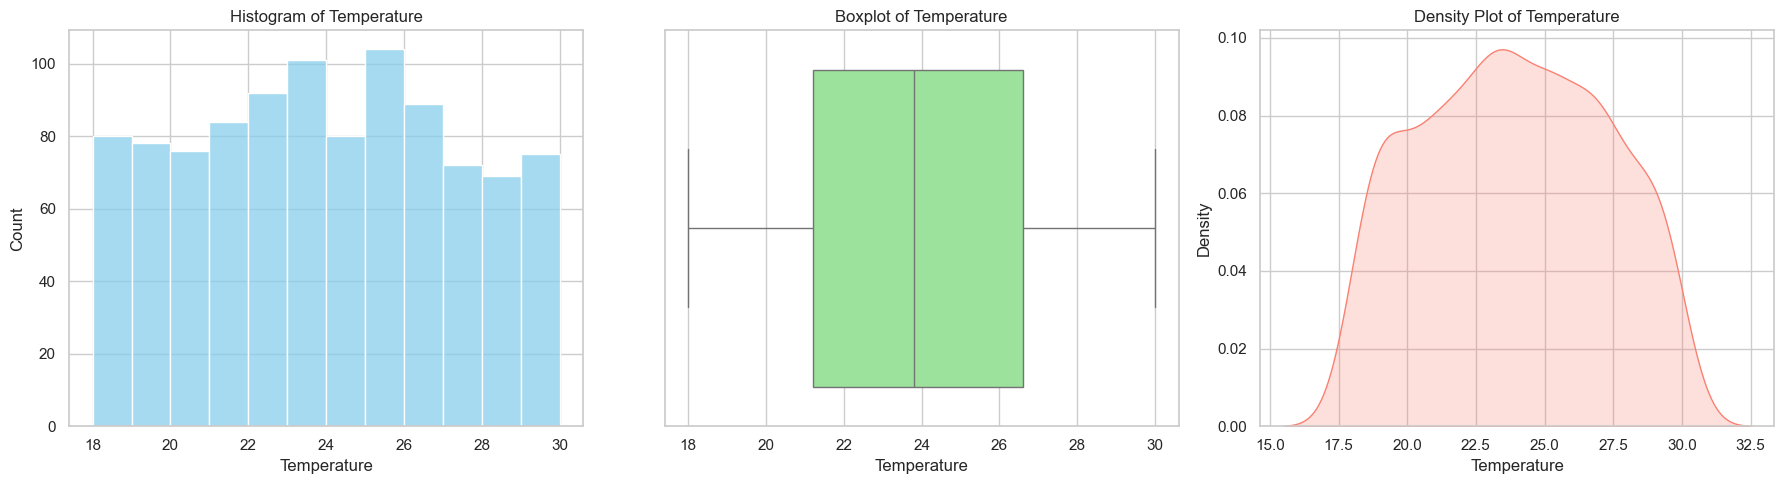

In [4]:
analyze_numerical('Temperature', df)

**Interpretation & Insight:**
Monitoring temperature is critical for perishable logistics. The metrics show the average operating conditions, while the boxplot highlights any deviations (outliers) that could risk product spoilage.

#### 3.x. Humidity

--- Humidity ---


,Measure,Value
0,Mean,65.04
1,Median,65.20
2,Mode,74.20
3,Variance,76.63
4,Standard Deviation,8.75
5,Minimum,50.00
6,Maximum,80.00
7,Q1 (25%),57.20
8,Q2 (50%),65.20
9,Q3 (75%),72.40


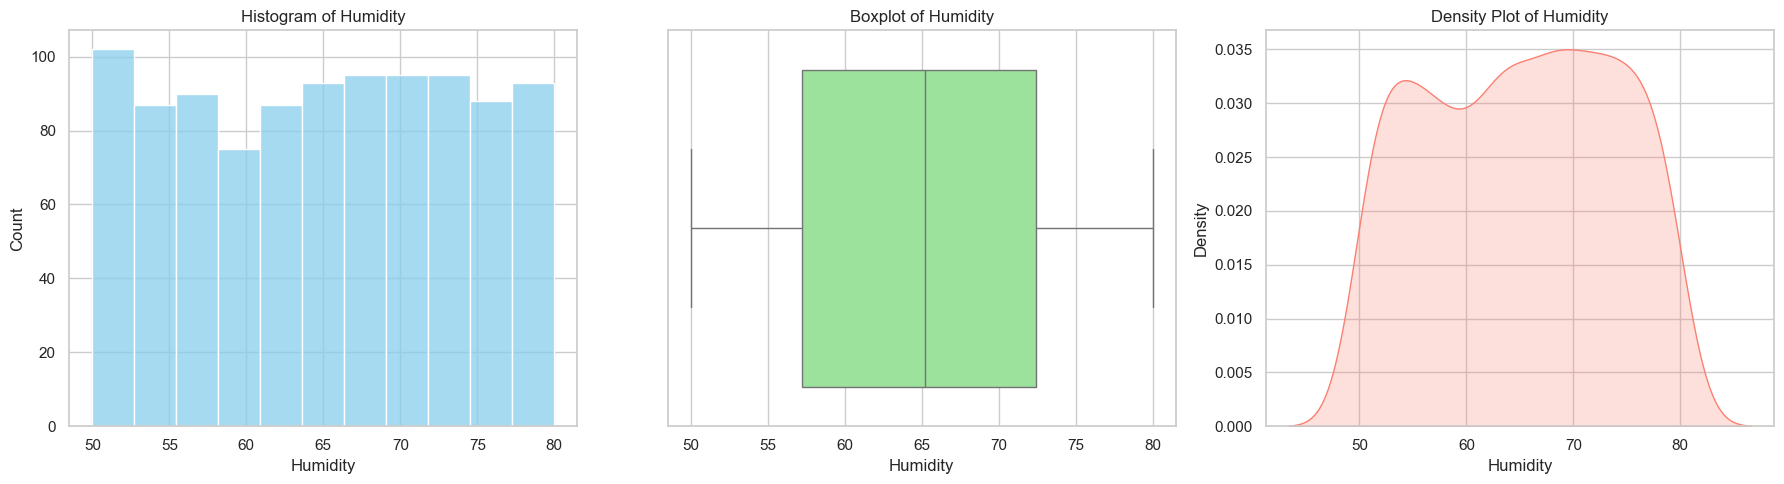

In [5]:
analyze_numerical('Humidity', df)

**Interpretation & Insight:**
Similar to temperature, humidity distribution impacts storage quality. The spread indicates the consistency of the environmental controls.

#### 3.x. Waiting_Time

--- Waiting_Time ---


,Measure,Value
0,Mean,35.06
1,Median,35.00
2,Mode,24.00
3,Variance,209.61
4,Standard Deviation,14.48
5,Minimum,10.00
6,Maximum,60.00
7,Q1 (25%),23.00
8,Q2 (50%),35.00
9,Q3 (75%),49.00


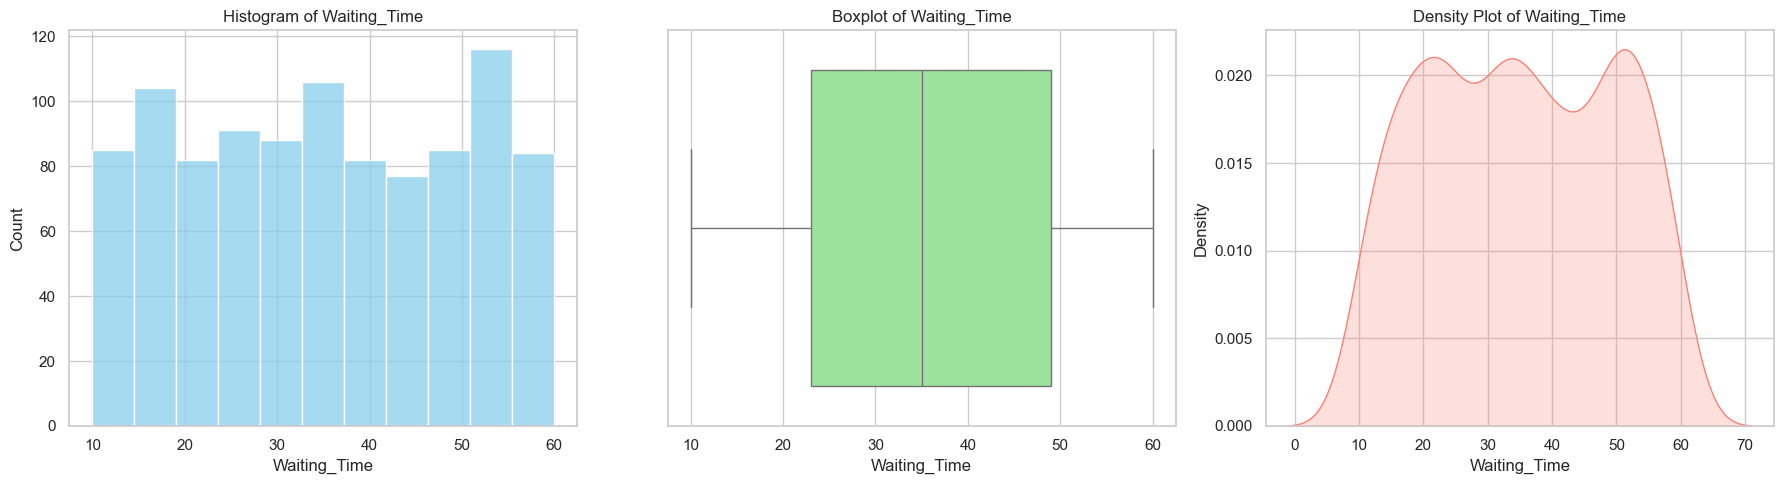

In [6]:
analyze_numerical('Waiting_Time', df)

**Interpretation & Insight:**
A critical KPI. The right-skewness typically seen in waiting times indicates that while most operations are efficient, there are long-tail instances causing significant delays. Addressing the outliers seen in the boxplot can improve overall efficiency.

#### 3.x. User_Transaction_Amount

--- User_Transaction_Amount ---


,Measure,Value
0,Mean,299.06
1,Median,301.50
2,Mode,421.00
3,Variance,13873.96
4,Standard Deviation,117.79
5,Minimum,100.00
6,Maximum,500.00
7,Q1 (25%),191.75
8,Q2 (50%),301.50
9,Q3 (75%),405.00


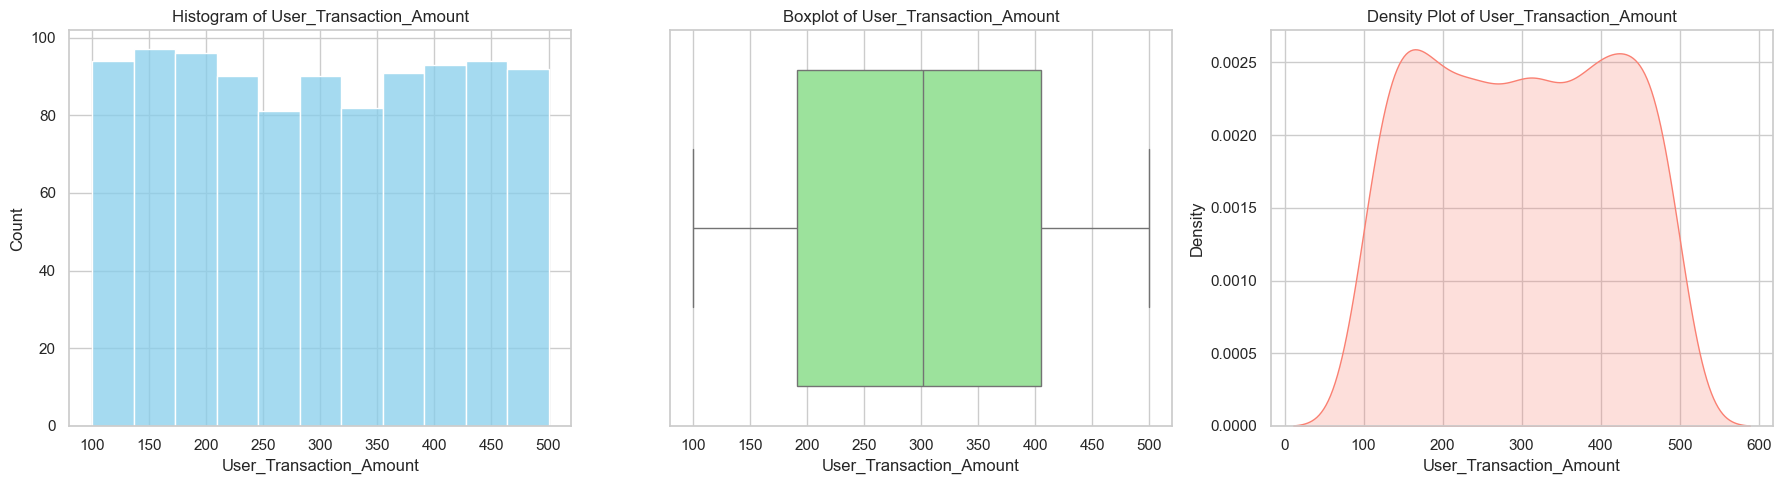

In [7]:
analyze_numerical('User_Transaction_Amount', df)

**Interpretation & Insight:**
This represents the monetary value associated with users. The distribution highlights spending behavior, often showing a concentrated average with some high-value outliers.

#### 3.x. User_Purchase_Frequency

--- User_Purchase_Frequency ---


,Measure,Value
0,Mean,5.51
1,Median,6.00
2,Mode,2.00
3,Variance,8.62
4,Standard Deviation,2.94
5,Minimum,1.00
6,Maximum,10.00
7,Q1 (25%),3.00
8,Q2 (50%),6.00
9,Q3 (75%),8.00


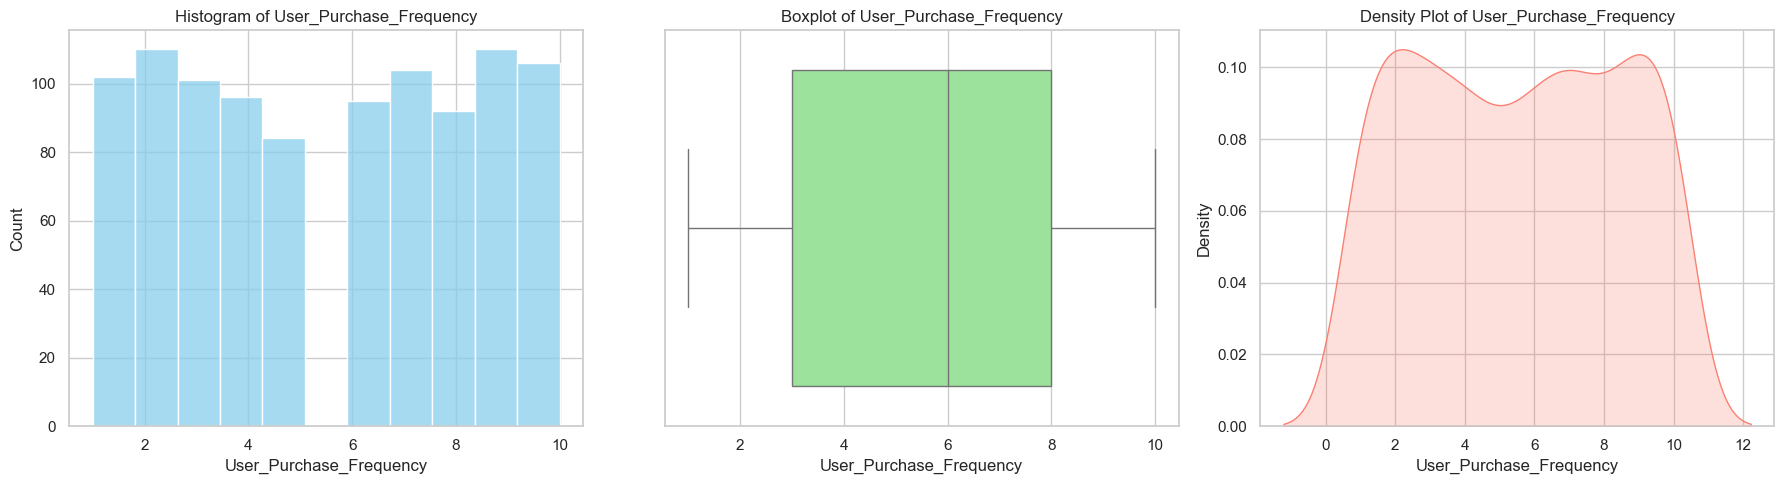

In [8]:
analyze_numerical('User_Purchase_Frequency', df)

**Interpretation & Insight:**
Indicates user engagement. The mode and median help establish the baseline customer behavior, which is useful for forecasting future demand.

#### 3.x. Asset_Utilization

--- Asset_Utilization ---


,Measure,Value
0,Mean,79.60
1,Median,79.25
2,Mode,66.80
3,Variance,135.28
4,Standard Deviation,11.63
5,Minimum,60.00
6,Maximum,100.00
7,Q1 (25%),69.47
8,Q2 (50%),79.25
9,Q3 (75%),89.43


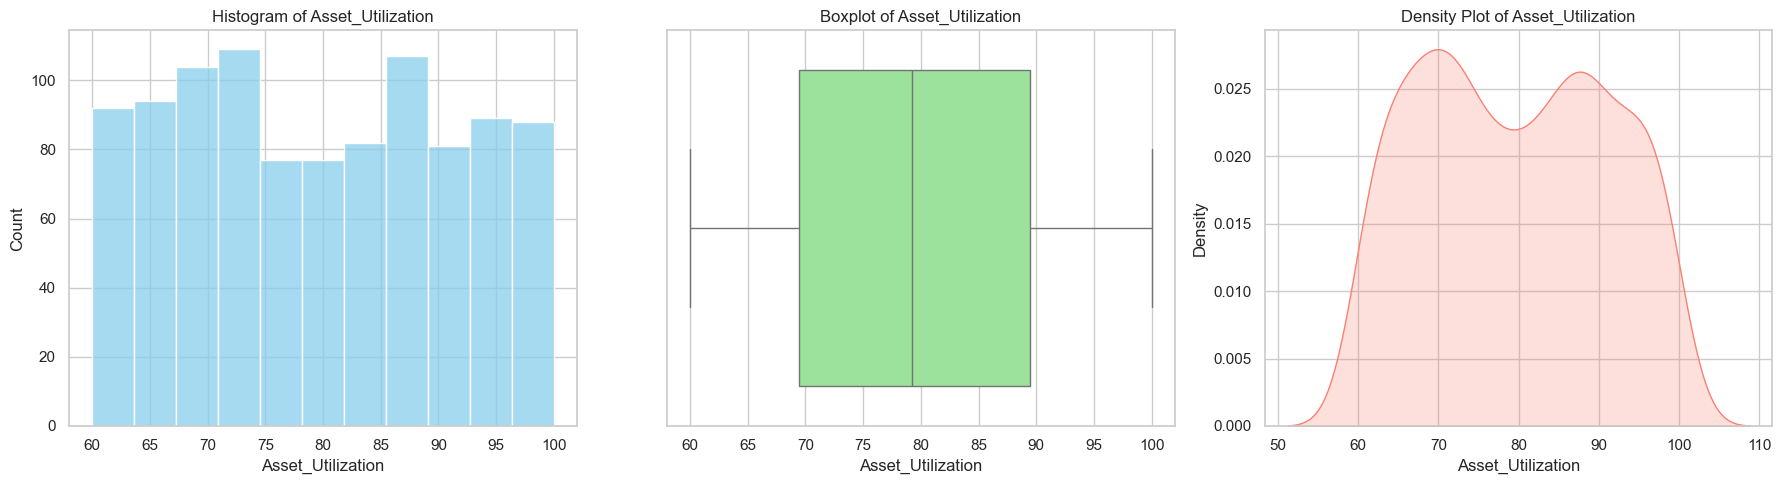

In [9]:
analyze_numerical('Asset_Utilization', df)

**Interpretation & Insight:**
Ideally, this should be concentrated at a high percentage without maxing out (which causes wear and tear). The density plot reveals if assets are generally underutilized or overutilized.

#### 3.x. Demand_Forecast

--- Demand_Forecast ---


,Measure,Value
0,Mean,199.28
1,Median,202.00
2,Mode,111.00
3,Variance,3590.51
4,Standard Deviation,59.92
5,Minimum,100.00
6,Maximum,300.00
7,Q1 (25%),144.00
8,Q2 (50%),202.00
9,Q3 (75%),251.25


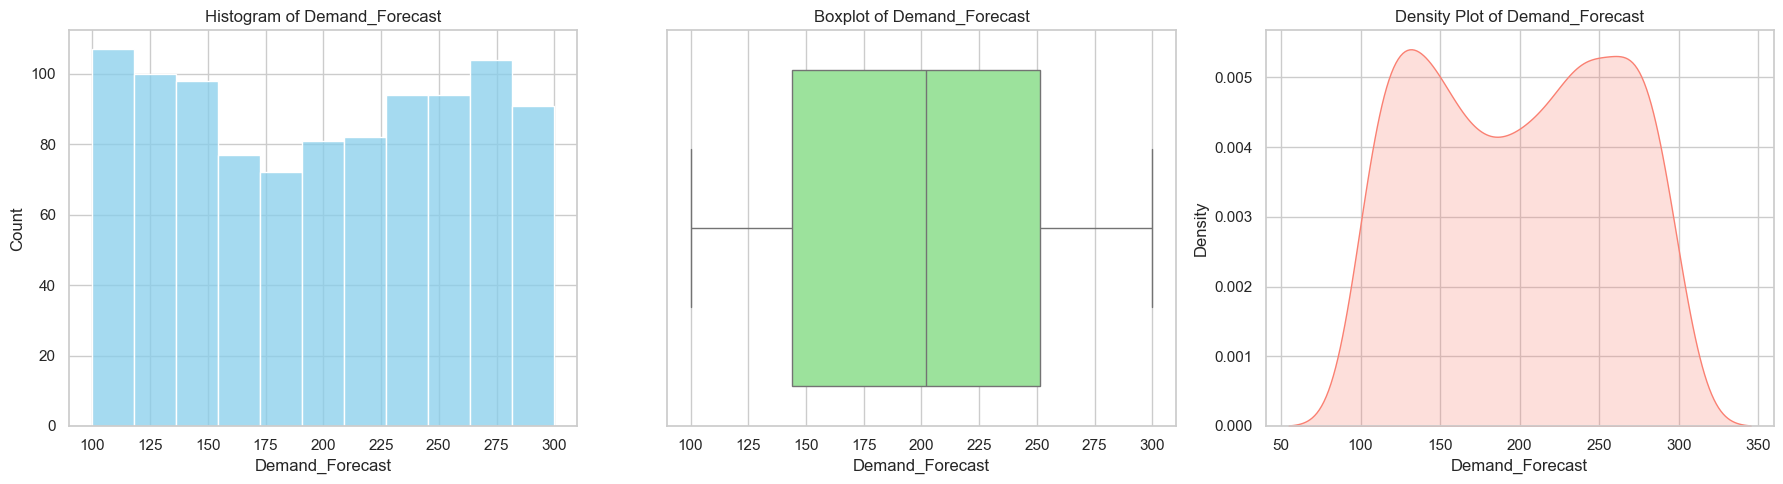

In [10]:
analyze_numerical('Demand_Forecast', df)

**Interpretation & Insight:**
Shows the anticipated volume. Comparing its variance with actual inventory levels can highlight alignment or mismatch in capacity planning.

### 4. Univariate Analysis: Categorical Columns
We will analyze categorical variables to understand segment sizes and operational statuses.


#### 4.x. Shipment_Status

--- Shipment_Status ---


,Count,Frequency,Percentage (%)
Shipment_Status,,,
Delayed,802,802,80.20%
On Schedule,198,198,19.80%


ValueError: 'red' is not a valid palette name

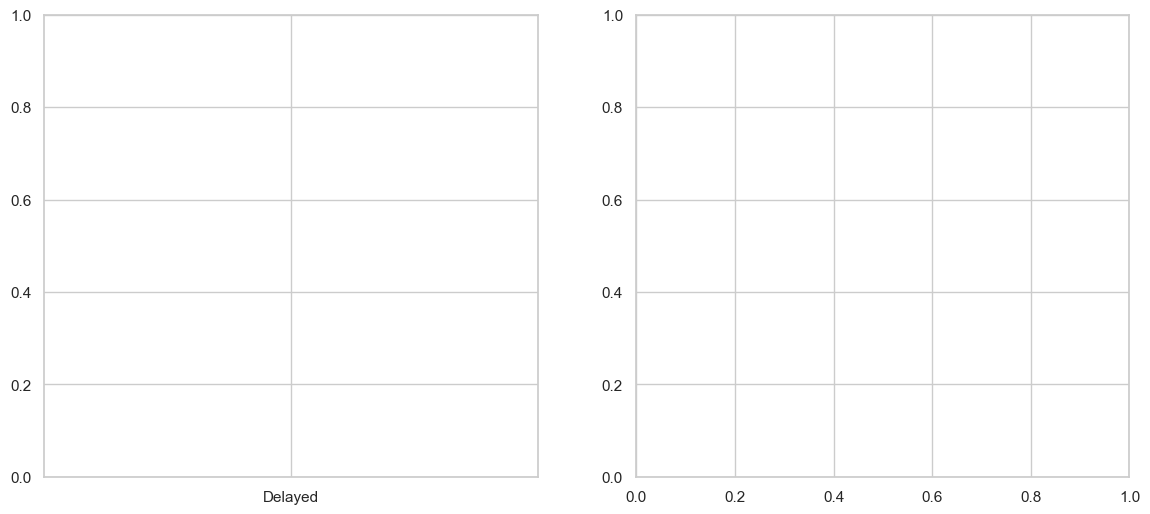

In [12]:
analyze_categorical('Shipment_Status', df)

**Business Insight:**
The bar chart provides a quick snapshot of overall logistics health. High proportions of 'Delayed' or 'Cancelled' indicate systemic issues, whereas a dominant 'Delivered' slice in the pie chart shows healthy operations.

#### 4.x. Traffic_Status

--- Traffic_Status ---


,Count,Frequency,Percentage (%)
Traffic_Status,,,
Heavy,981,981,98.10%
Moderate,19,19,1.90%


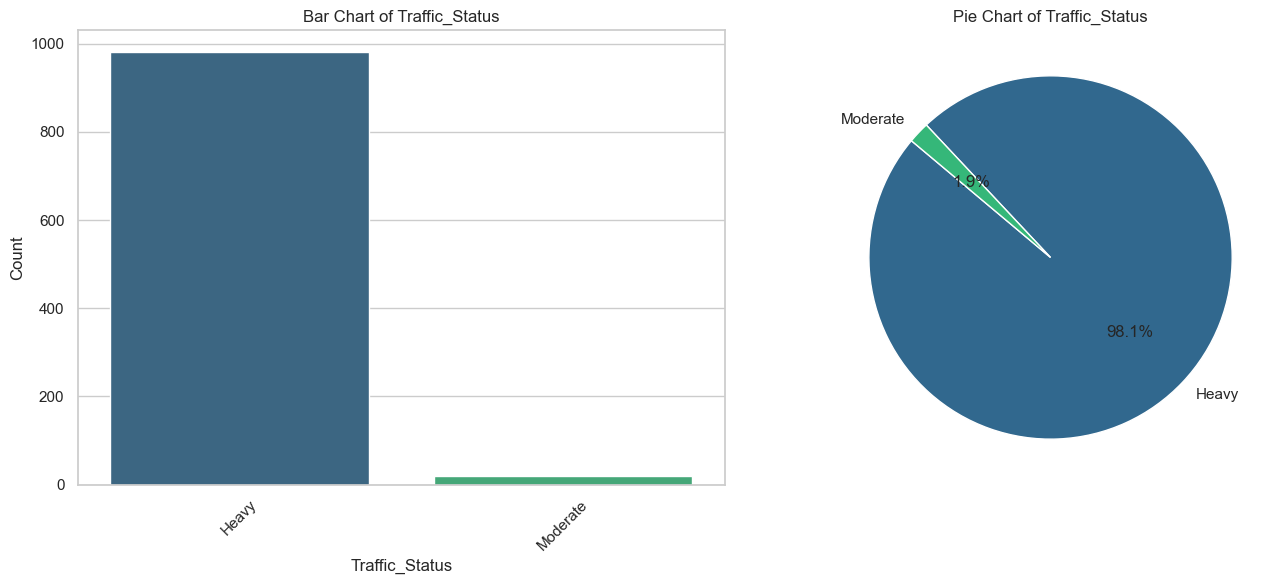

In [ ]:
analyze_categorical('Traffic_Status', df)

**Business Insight:**
Understanding the breakdown of traffic conditions (e.g., Heavy, Moderate, Light) contextualizes delivery performance. If 'Heavy' traffic is highly frequent, routing optimizations are urgently needed.

#### 4.x. Logistics_Delay_Reason

--- Logistics_Delay_Reason ---


,Count,Frequency,Percentage (%)
Logistics_Delay_Reason,,,
Low Inventory,538,538,67.08%
Traffic Congestion,264,264,32.92%


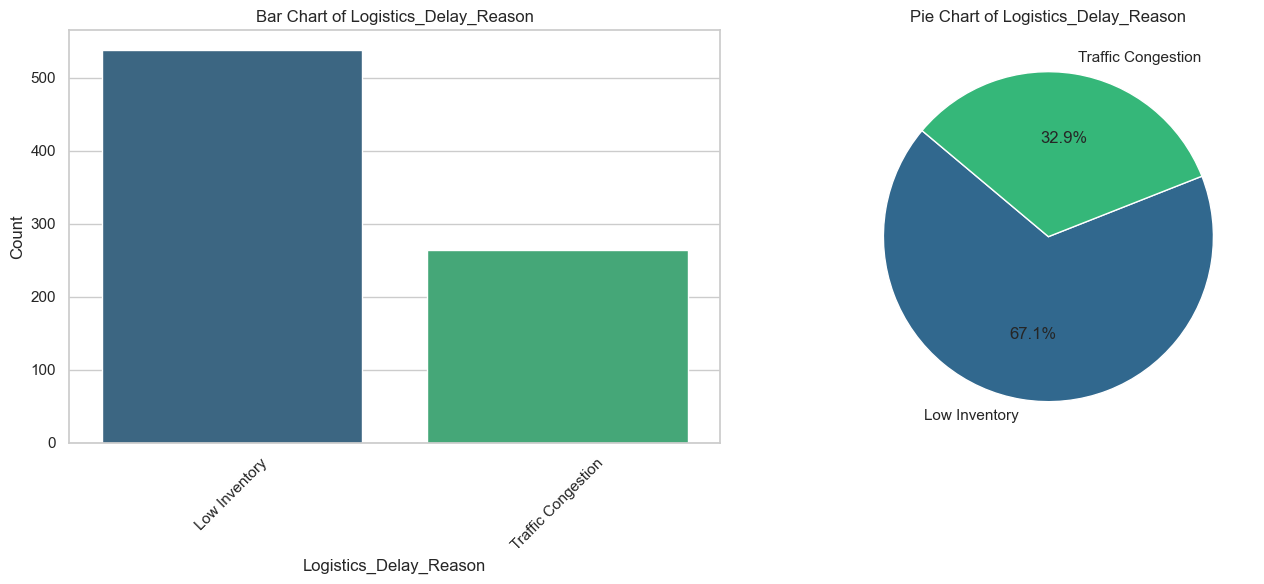

In [ ]:
analyze_categorical('Logistics_Delay_Reason', df)

**Business Insight:**
This is the most actionable insight. The Pareto principle often applies here�identifying the top 1-2 delay reasons from the bar chart allows management to focus improvement efforts where they will have the most impact. 'No Delay' serves as our baseline.

#### 4.x. Logistics_Delay

--- Logistics_Delay ---


,Count,Frequency,Percentage (%)
Logistics_Delay,,,
1,802,802,80.20%
0,198,198,19.80%


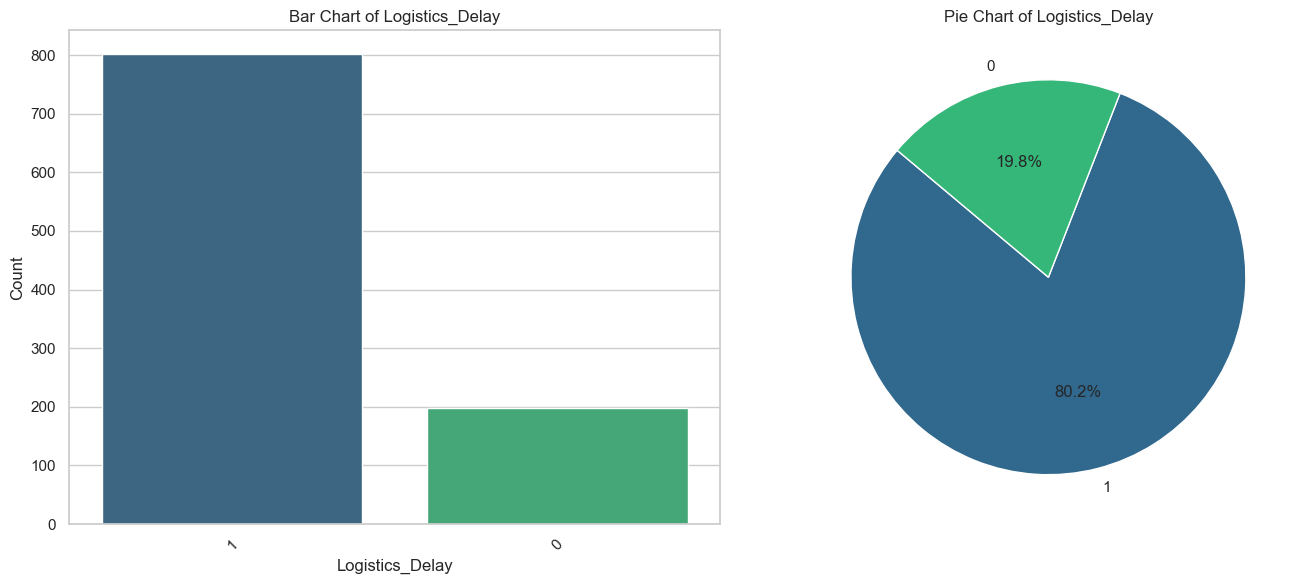

In [ ]:
analyze_categorical('Logistics_Delay', df)

**Business Insight:**
This binary flag (0=No, 1=Yes) encapsulates the ultimate success rate of the logistics network. The percentage split shown in the pie chart is the primary metric for tracking overall reliability.

### 5. Day 3 Conclusion
We have successfully completed a comprehensive Univariate Analysis. 

**Key Takeaways:**
- We've established baseline statistics (Mean, Median, Mode, Min, Max) for all critical numerical KPIs.
- Discovered distributional shapes and outliers using Histograms, Boxplots, and Density Plots.
- Mapped the frequency and impact of categorical variables, specifically pinning down delay reasons and shipment statuses.

These insights form the foundation for **Bivariate Analysis** (Day 4), where we will investigate relationships between these variables (e.g., How does Traffic_Status affect Waiting_Time?).
